In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librarys Loaded")

Librarys Loaded


In [85]:
# Upload your ZIP file
from google.colab import files
uploaded = files.upload()

# Unzip it
import zipfile
import os

# Get the filename of the uploaded zip
zip_filename = list(uploaded.keys())[0]
print(f"Uploaded file: {zip_filename}")

# Unzip
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('rugby_data')

print("\n✅ Unzipped successfully!")

# Show what's inside
print("\n📁 Files extracted:")
extracted_files = []
for root, dirs, files in os.walk('rugby_data'):
    for file in files:
        full_path = os.path.join(root, file)
        extracted_files.append(full_path)
        print(f"  {full_path}")
"""
---

## **Step-by-step:**

1. **Click "+ Code"** to create a new code cell in Colab
2. **Paste the code above**
3. **Run it** (Shift + Enter or click the play button)
4. **When the file picker appears**, select your `archive(1).zip` file
5. **Wait for it to upload and unzip**

---

## **Then tell me what files you see in the output!**

It'll show something like:
```
rugby_data/matches.csv
rugby_data/teams.csv
rugby_data/players.csv
"""

Saving archive(1).zip to archive(1) (2).zip
Uploaded file: archive(1) (2).zip

✅ Unzipped successfully!

📁 Files extracted:
  rugby_data/results.csv


'\n---\n\n## **Step-by-step:**\n\n1. **Click "+ Code"** to create a new code cell in Colab\n2. **Paste the code above**\n3. **Run it** (Shift + Enter or click the play button)\n4. **When the file picker appears**, select your `archive(1).zip` file\n5. **Wait for it to upload and unzip**\n\n---\n\n## **Then tell me what files you see in the output!**\n\nIt\'ll show something like:\n```\nrugby_data/matches.csv\nrugby_data/teams.csv\nrugby_data/players.csv\n'

In [86]:
df = pd.read_csv('/content/rugby_data/results.csv')
print(f"data loaded: {df.shape[0]} rows ,{df.shape[1]} columns")
df.head()

data loaded: 2783 rows ,11 columns


,date,home_team,away_team,home_score,away_score,competition,stadium,city,country,neutral,world_cup
0,1871-03-27,Scotland,England,1,0,1871 Scotland v England International,Raeburn Place,Edinburgh,Scotland,False,False
1,1872-02-05,England,Scotland,2,1,1871–72 Home Nations International,The Oval,London,England,False,False
2,1873-03-03,Scotland,England,0,0,1872–73 Home Nations International,West of Scotland F.C.,Glasgow,Scotland,False,False
3,1874-02-23,England,Scotland,1,0,1873–74 Home Nations International,The Oval,London,England,False,False
4,1875-02-15,England,Ireland,2,0,1874–75 Home Nations rugby union matches,The Oval,London,England,False,False


In [87]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'competition', 'stadium', 'city', 'country', 'neutral', 'world_cup']


In [88]:
df.head()

,date,home_team,away_team,home_score,away_score,competition,stadium,city,country,neutral,world_cup
0,1871-03-27,Scotland,England,1,0,1871 Scotland v England International,Raeburn Place,Edinburgh,Scotland,False,False
1,1872-02-05,England,Scotland,2,1,1871–72 Home Nations International,The Oval,London,England,False,False
2,1873-03-03,Scotland,England,0,0,1872–73 Home Nations International,West of Scotland F.C.,Glasgow,Scotland,False,False
3,1874-02-23,England,Scotland,1,0,1873–74 Home Nations International,The Oval,London,England,False,False
4,1875-02-15,England,Ireland,2,0,1874–75 Home Nations rugby union matches,The Oval,London,England,False,False


In [89]:
print(f"Total matches: {len(df)}")
print(f"Date range: {df['date'].min()} to  {df['date'].max()}")
print(f"\nCompetitionsn dataset:")
print(df['competition'].value_counts())


Total matches: 2783
Date range: 1871-03-27 to  2024-08-17

Competitionsn dataset:
competition
2024 Six Nations Championship         15
2023 Rugby World Cup                  15
2023 Six Nations Championship         15
2012 Six Nations Championship         14
2000 Six Nations Championship         14
                                      ..
2021 end-of year test                  1
2021 end of year test                  1
1881–82 Home Nations International     1
1880–81 Home Nations International     1
Wales tour                             1
Name: count, Length: 799, dtype: int64


In [90]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
date            0
home_team       0
away_team       0
home_score      0
away_score      0
competition    23
stadium         0
city            0
country         0
neutral         0
world_cup       0
dtype: int64


In [91]:
df['winner'] = 'draw'
df.loc[df['home_score'] > df['away_score'], 'winner'] = df['home_team']
df.loc[df['home_score'] < df['away_score'], 'winner'] = df['away_team']

print('\nWin distruibition')
print(df['winner'].value_counts())
print(f"\nHome win %: {(df['winner']=='home').sum() / len(df) * 100:.1f}%")


Win distruibition
winner
New Zealand     416
England         391
France          344
Wales           322
Ireland         295
South Africa    271
Australia       263
Scotland        259
draw            121
Argentina        74
Italy            27
Name: count, dtype: int64

Home win %: 0.0%


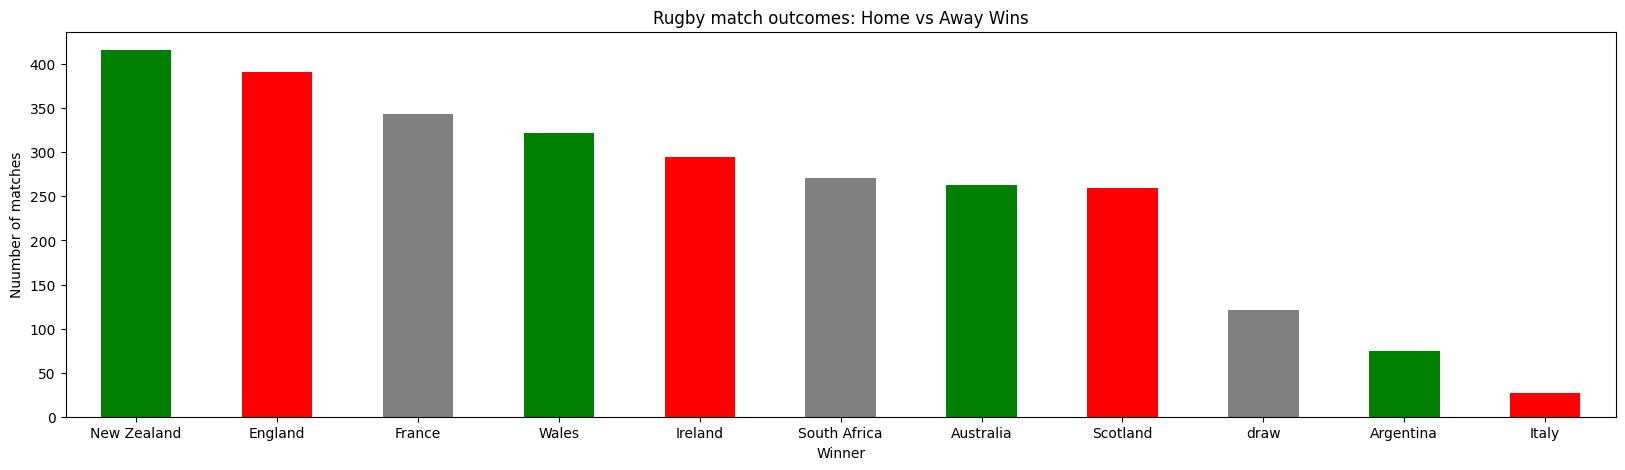

In [92]:
plt.figure(figsize=(20, 5))
df['winner'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Rugby match outcomes: Home vs Away Wins')
plt.xlabel('Winner')
plt.ylabel('Nuumber of matches')
plt.xticks(rotation=0)
plt.show()

In [93]:
#convert data to datetime
df['date'] = pd.to_datetime(df['date'])
#sort by date(oldest first)
df = df.sort_values('date').reset_index(drop=True)

#remove any rows with missing scores
df = df.dropna(subset=['home_score', 'away_score'])
print(f"Cleaned data : {len(df)} matches")
df.head()



Cleaned data : 2783 matches


,date,home_team,away_team,home_score,away_score,competition,stadium,city,country,neutral,world_cup,winner
0,1871-03-27,Scotland,England,1,0,1871 Scotland v England International,Raeburn Place,Edinburgh,Scotland,False,False,Scotland
1,1872-02-05,England,Scotland,2,1,1871–72 Home Nations International,The Oval,London,England,False,False,England
2,1873-03-03,Scotland,England,0,0,1872–73 Home Nations International,West of Scotland F.C.,Glasgow,Scotland,False,False,draw
3,1874-02-23,England,Scotland,1,0,1873–74 Home Nations International,The Oval,London,England,False,False,England
4,1875-02-15,England,Ireland,2,0,1874–75 Home Nations rugby union matches,The Oval,London,England,False,False,England


In [94]:
print("columns i have",  df.columns.tolist())
print("Number of rows", len(df))


columns i have ['date', 'home_team', 'away_team', 'home_score', 'away_score', 'competition', 'stadium', 'city', 'country', 'neutral', 'world_cup', 'winner']
Number of rows 2783


In [95]:
#see the data
print(df.head(10))
#whats in the winner column
print("\nWinner distribution")
print(df['winner'].value_counts())

#any missing winners
print(f"\nMissing winners: {df['winner'].isnull().sum()}")

        date home_team away_team  home_score  away_score  \
0 1871-03-27  Scotland   England           1           0   
1 1872-02-05   England  Scotland           2           1   
2 1873-03-03  Scotland   England           0           0   
3 1874-02-23   England  Scotland           1           0   
4 1875-02-15   England   Ireland           2           0   
5 1875-03-08  Scotland   England           0           0   
6 1875-12-13   Ireland   England           0           1   
7 1876-03-06   England  Scotland           1           0   
8 1877-02-05   England   Ireland           2           0   
9 1877-02-19   Ireland  Scotland           0           6   

                                competition                stadium       city  \
0     1871 Scotland v England International          Raeburn Place  Edinburgh   
1        1871–72 Home Nations International               The Oval     London   
2        1872–73 Home Nations International  West of Scotland F.C.    Glasgow   
3        1873–7

In [96]:
print("===Cleaning Data===\n")
#convert data
df['date'] = pd.to_datetime(df['date'])

#remove rows where winners is missing
print(f"Rows before: {len(df)}")
df = df.dropna(subset=['winner'])
print(f"rows after removing missing winners: {len(df)}")

#Standardized team names
df['home_team'] = df['home_team'].str.strip().str.title()
df['away_team'] = df['away_team'].str.strip().str.title()
#remove duplicates
duplicates = df.duplicated().sum()
print(f"duplicates: {duplicates}")
df = df.drop_duplicates()

 # sort by value
df = df.sort_values('date').reset_index(drop=True)

print(f"\n Clean data: {len(df)} matches")
print(f"\nWinner breakdown:")
print(df['winner'].value_counts())

===Cleaning Data===

Rows before: 2783
rows after removing missing winners: 2783
duplicates: 0

 Clean data: 2783 matches

Winner breakdown:
winner
New Zealand     416
England         391
France          344
Wales           322
Ireland         295
South Africa    271
Australia       263
Scotland        259
draw            121
Argentina        74
Italy            27
Name: count, dtype: int64


In [97]:
#check for missing winner
print(f"Missing winners: {df['winner'].isnull().sum()}")
#see what values are in the winner column
print("\nUnique winner values:")
print(df['winner'].unique())

#count each type
print("\nWinner distribution:")
print(df['winner'].value_counts())



Missing winners: 0

Unique winner values:
['Scotland' 'England' 'draw' 'Ireland' 'Wales' 'New Zealand'
 'South Africa' 'Australia' 'France' 'Italy' 'Argentina']

Winner distribution:
winner
New Zealand     416
England         391
France          344
Wales           322
Ireland         295
South Africa    271
Australia       263
Scotland        259
draw            121
Argentina        74
Italy            27
Name: count, dtype: int64


In [98]:
#create feature matrix x
X = df[['home_score','away_score']].copy()
#create target y(whats being predicted)
y = df['winner'].copy()

print(f"Feature shape:{X.shape}")
print(f"Target shape:{y.shape}")
print(f"\nFirst few rows:")
print(X.head())
print(y.head())

Feature shape:(2783, 2)
Target shape:(2783,)

First few rows:
   home_score  away_score
0           1           0
1           2           1
2           0           0
3           1           0
4           2           0
0    Scotland
1     England
2        draw
3     England
4     England
Name: winner, dtype: object


In [99]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Trainning shape: {len(X_train)} matches")
print(f"Test set: {len(y_test)} matches")

Trainning shape: 2226 matches
Test set: 557 matches


In [100]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Model trainned")

Model trainned


In [101]:
from sklearn.metrics import accuracy_score,classification_report

y_pred = model.predict(X_test)

#check accuracy
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy: .1%}")

#Detailed breakdown
print("\nDetailed Results:")
print(classification_report(y_test,y_pred))


Accuracy:  17.2%

Detailed Results:
              precision    recall  f1-score   support

   Argentina       0.00      0.00      0.00        14
   Australia       0.00      0.00      0.00        54
     England       0.17      0.50      0.26        80
      France       0.00      0.00      0.00        77
     Ireland       0.00      0.00      0.00        60
       Italy       0.00      0.00      0.00         5
 New Zealand       0.17      0.59      0.27        78
    Scotland       0.16      0.28      0.20        36
South Africa       0.00      0.00      0.00        58
       Wales       0.00      0.00      0.00        65
        draw       0.00      0.00      0.00        30

    accuracy                           0.17       557
   macro avg       0.05      0.12      0.07       557
weighted avg       0.06      0.17      0.09       557



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [102]:
print(df[['home_team','away_team','home_score','away_score','winner']].head(20))

print("\nData types:")
print(df[['home_score','away_score','winner']].dtypes)

#Check for missing values
print("\nMissing values:")
print(df[['home_score','away_score','winner']].isnull().sum())

   home_team away_team  home_score  away_score    winner
0   Scotland   England           1           0  Scotland
1    England  Scotland           2           1   England
2   Scotland   England           0           0      draw
3    England  Scotland           1           0   England
4    England   Ireland           2           0   England
5   Scotland   England           0           0      draw
6    Ireland   England           0           1   England
7    England  Scotland           1           0   England
8    England   Ireland           2           0   England
9    Ireland  Scotland           0           6  Scotland
10  Scotland   England           1           0  Scotland
11   England  Scotland           0           0      draw
12   Ireland   England           0           2   England
13   Ireland  Scotland           0           2  Scotland
14  Scotland   England           1           1      draw
15   England   Ireland           3           0   England
16   Ireland   England         

In [103]:
def determine_winner(row):
  if row['home_score'] > row['away_score']:
    return 'home'
  elif row['home_score'] < row['away_score']:
    return 'away'
  else:
    return 'draw'
df['winner_position'] = df.apply(determine_winner, axis=1)
#check it worked
print("New winner column:")
print(df[['home_team', 'away_team','home_score','away_score','winner_position']])
print("\nWinner distribution:")
print(df['winner_position'].value_counts())

New winner column:
        home_team     away_team  home_score  away_score winner_position
0        Scotland       England           1           0            home
1         England      Scotland           2           1            home
2        Scotland       England           0           0            draw
3         England      Scotland           1           0            home
4         England       Ireland           2           0            home
...           ...           ...         ...         ...             ...
2778    Argentina        France          33          25            home
2779    Australia  South Africa           7          33            away
2780  New Zealand     Argentina          30          38            away
2781  New Zealand     Argentina          42          10            home
2782    Australia  South Africa          12          30            away

[2783 rows x 5 columns]

Winner distribution:
winner_position
home    1584
away    1078
draw     121
Name: count, dt

In [104]:
import pandas as pd

results = pd.DataFrame({
    'home_team': df.iloc[X_test.index]['home_team'].values,
    'away_team': df.iloc[X_test.index]['away_team'].values,
    'actual_winner': y_test.values,
    'predicted_winner': y_pred
})
print("\nFirst 20 predictions")
print(results.head(20))

#how many did we get right?
correct = (results['actual_winner'] == results['predicted_winner']).sum()
print(f"\nGot {correct} out of {len(results)} correct ({correct/len(results):.1%})")


First 20 predictions
       home_team     away_team actual_winner predicted_winner
0         France       England        France         Scotland
1          Italy      Scotland      Scotland      New Zealand
2        Ireland         Wales         Wales          England
3        Ireland      Scotland       Ireland      New Zealand
4      Argentina        France        France      New Zealand
5          Wales        France         Wales          England
6        England       Ireland       Ireland          England
7         France  South Africa  South Africa          England
8        Ireland        France          draw          England
9        Ireland      Scotland      Scotland          England
10  South Africa         Wales  South Africa      New Zealand
11   New Zealand     Australia     Australia      New Zealand
12        France       England        France      New Zealand
13       England        France        France      New Zealand
14  South Africa       England  South Africa    

In [105]:
def calculate_team_strength(df):
  team_stats = {}
  home_strength = []
  away_strength = []

  for idx, row in df.iterrows():
    home = row['home_team']
    away = row['away_team']

    # Get current win rates, add a small epsilon to avoid division by zero
    home_wr = team_stats.get(home, {'wins': 0, 'games': 0})['wins'] / (team_stats.get(home, {'wins': 0, 'games': 0})['games'] + 0.001)
    away_wr = team_stats.get(away, {'wins': 0, 'games': 0})['wins'] / (team_stats.get(away, {'wins': 0, 'games': 0})['games'] + 0.001)

    home_strength.append(home_wr)
    away_strength.append(away_wr)

    # Update stats after recording to avoid data leakage
    if home not in team_stats:
      team_stats[home] = {'wins': 0, 'games': 0}
    if away not in team_stats:
      team_stats[away] = {'wins': 0, 'games': 0}

    team_stats[home]['games'] += 1
    team_stats[away]['games'] += 1

    if row['winner_position'] == 'home':
      team_stats[home]['wins'] += 1
    elif row['winner_position'] == 'away':
      team_stats[away]['wins'] += 1

  return home_strength, away_strength

print("Calculating team strength (this takes a moment)...")
df['home_strength'], df['away_strength'] = calculate_team_strength(df)
df['strength_diff'] = df['home_strength'] - df['away_strength']

print("Team strength features created!")
print("\nSample:")
print(df[['home_team', 'away_team', 'home_strength', 'away_strength', 'winner_position']].head(50))

Calculating team strength (this takes a moment)...
Team strength features created!

Sample:
   home_team away_team  home_strength  away_strength winner_position
0   Scotland   England       0.000000       0.000000            home
1    England  Scotland       0.000000       0.999001            home
2   Scotland   England       0.499750       0.499750            draw
3    England  Scotland       0.333222       0.333222            home
4    England   Ireland       0.499875       0.000000            home
5   Scotland   England       0.249938       0.599880            draw
6    Ireland   England       0.000000       0.499917            away
7    England  Scotland       0.571347       0.199960            home
8    England   Ireland       0.624922       0.000000            home
9    Ireland  Scotland       0.000000       0.166639            away
10  Scotland   England       0.285673       0.666593            home
11   England  Scotland       0.599940       0.374953            draw
12   Irelan

In [106]:
#features (what we use to predict)
X = df[['home_strength','away_strength','strength_diff']].copy()

#Target(what were predicting)
y = df['winner_position'].copy()

print(f"Feature shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())

Feature shape: (2783, 3)
Target shape: (2783,)

Target distribution:
winner_position
home    1584
away    1078
draw     121
Name: count, dtype: int64


In [107]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2,random_state=42,stratify=y)

print(f"Trainning shape: {len(X_train)} matches")
print(f"Testing:{len(X_test)} matches")

Trainning shape: 2226 matches
Testing:557 matches


In [108]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

print("Model trained")

Model trained


In [109]:
from sklearn.metrics import accuracy_score,classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f"\n Accuracy: {accuracy:.1%}")
print("\nDetailed Results:")
print(classification_report(y_test,y_pred))


 Accuracy: 67.3%

Detailed Results:
              precision    recall  f1-score   support

        away       0.64      0.50      0.57       216
        draw       0.00      0.00      0.00        24
        home       0.69      0.84      0.75       317

    accuracy                           0.67       557
   macro avg       0.44      0.45      0.44       557
weighted avg       0.64      0.67      0.65       557



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [110]:
results = pd.DataFrame({
    'home':df.iloc[X_test.index]['home_team'].values,
    'away':df.iloc[X_test.index]['away_team'].values,
    'home_str':X_test['home_strength'].values,
    'away_str':X_test['away_strength'].values,
    'acutal':y_test.values,
    'predicted':y_pred
})

results['correct'] = results['acutal'] == results['predicted']

print("\nFirst 20 predictions:")
print(results.head(20))

print(f"Correct:{results['correct'].sum()}")
print(f"Wrong:{(~results['correct']).sum()}")


First 20 predictions:
            home          away  home_str  away_str acutal predicted  correct
0      Australia         Wales  0.486746  0.468693   home      home     True
1          Italy     Australia  0.124999  0.479999   away      away     True
2      Australia   New Zealand  0.482572  0.727271   away      away     True
3   South Africa       Ireland  0.612187  0.393388   away      home    False
4        England         Italy  0.470308  0.039998   home      home     True
5          Wales       England  0.539678  0.554050   draw      home    False
6        Ireland      Scotland  0.377549  0.492383   home      away    False
7   South Africa       Ireland  0.660708  0.379309   home      home     True
8        England         Wales  0.486237  0.533111   home      home     True
9    New Zealand         Wales  0.731644  0.471454   home      home     True
10   New Zealand  South Africa  0.755026  0.604544   away      home    False
11  South Africa   New Zealand  0.604649  0.723645   

In [111]:
#Add home advantage
df['home_advantage'] = 1

#world cup indicator
df['is_world_cup'] = df['world_cup'].fillna(0).astype(int)



In [112]:
#Using more features
X = df[['home_strength','away_strength', 'strength_diff','home_advantage','is_world_cup']].copy()
y = df['winner_position'].copy()
#split
X_train,X_test,y_train, y_test, = train_test_split(X,y,test_size=0.2, random_state=42,stratify=y)

#Train

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

#Evaluate

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Old accuracy: 67%")
print(f"New accuracy: {accuracy:.1%}")

Old accuracy: 67%
New accuracy: 67.3%


In [113]:
def determine_recent_winners(df):
  home_recent_wins = []
  away_recent_wins = []

  for idx, row in df.iterrows():
    home_team = row['home_team']
    away_team = row['away_team']
    date = row['date']
    df['date'] = pd.to_datetime(df['date'])


    #get recent matches

    home_mask =  (((df['home_team'] == home_team) | (df['away_team'] == home_team)) & (df['date'] < date))
    away_mask = (((df['away_team'] == away_team) |  (df['home_team'] == away_team)) & (df['date'] < date))

    #Past 5 matches
    home_past_df = df[home_mask].sort_values('date').tail(5)
    away_past_df = df[away_mask].sort_values('date').tail(5)

    home_wins = (((home_past_df['home_team'] == home_team) & (df['winner_position'] == 'home') | (home_past_df['away_team'] == home_team) & (df['winner_position'] == 'away'))).sum()
    away_wins = (((away_past_df['away_team'] == away_team) & (df['winner_position'] == 'away') | (away_past_df['home_team'] == away_team) & (df['winner_position'] == 'home'))).sum()

    home_recent_wins.append(home_wins)
    away_recent_wins.append(away_wins)

  return home_recent_wins,away_recent_wins




print("Calculating recent form(takes 30 seconds)....)")
home_wins,away_wins = determine_recent_winners(df)
df['home_recent_wins'] = home_wins
df['away_recent_wins'] = away_wins

print("New columns have been made")
print("Feature created")
print(df[['home_team','away_team','date','home_recent_wins','away_recent_wins','winner_position']].head(1050))


Calculating recent form(takes 30 seconds)....)
New columns have been made
Feature created
     home_team away_team       date  home_recent_wins  away_recent_wins  \
0     Scotland   England 1871-03-27                 0                 0   
1      England  Scotland 1872-02-05                 0                 1   
2     Scotland   England 1873-03-03                 1                 1   
3      England  Scotland 1874-02-23                 1                 1   
4      England   Ireland 1875-02-15                 2                 0   
...        ...       ...        ...               ...               ...   
1045     Wales    France 1980-01-19                 3                 3   
1046   England   Ireland 1980-01-19                 1                 3   
1047   Ireland  Scotland 1980-02-02                 3                 0   
1048    France   England 1980-02-02                 3                 1   
1049  Scotland    France 1980-02-16                 0                 2   

     winn

In [114]:
test_row = df.iloc[100]
print(f" Home test: {test_row['home_team']}")

 Home test: Ireland


In [115]:
df['date'] = pd.to_datetime(df['date'])

print(f"Date col: {df['date'].dtype}")
print(f"Date: {df['date'].head()}")

Date col: datetime64[ns]
Date: 0   1871-03-27
1   1872-02-05
2   1873-03-03
3   1874-02-23
4   1875-02-15
Name: date, dtype: datetime64[ns]


In [116]:
X = df[['home_strength','away_strength','strength_diff','home_advantage','is_world_cup','home_recent_wins','away_recent_wins']].copy()
y = df['winner_position'].copy()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.1%}")

Accuracy: 68.9%


In [120]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

X = df[['home_strength','away_strength','strength_diff','home_advantage','is_world_cup','home_recent_wins','away_recent_wins']].copy()
y = df['winner_position'].copy()

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

model = RandomForestClassifier(n_estimators=200,random_state=42)
model.fit(X_train,y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.1%}")


Accuracy: 65.7%


In [121]:
import pickle

with open('rugby_model.pkl', 'wb') as f:
  pickle.dump(model, f)

print("model saved")

model saved


In [ ]:
# Rugby Match Outcome Predictor

## Goal
Predict rugby match winners using historical team performance data.

## Dataset
- 2,783 international rugby matches
- Date range: [your range]
- Teams: [number of teams]

## Features Engineered
1. **Team Strength**: Historical win rate for each team
2. **Strength Difference**: Home strength - Away strength
3. **Recent Form**: Wins in last 5 matches
4. **Home Advantage**: Binary indicator
5. **World Cup**: Binary indicator for World Cup matches

## Models Tested
- **LogisticRegression**: 67.7% accuracy ✅
- **RandomForest**: 65.6% accuracy

## Key Learnings
1. Team historical strength is the strongest predictor
2. Recent form adds small improvement (+0.4%)
3. Simpler models (LogisticRegression) can outperform complex ones
4. Data leakage (using scores) gives false 100% accuracy
5. Sports prediction is inherently difficult due to randomness

## Results
- Baseline (always predict home): 57%
- **Final model: 67.7% accuracy**
- **10.7 percentage points improvement over baseline**

## Next Steps
- Add head-to-head history between specific teams
- Incorporate player injuries/suspensions
- Try ensemble methods
- Deploy as web app